<a href="https://colab.research.google.com/github/aligreo/TriEncoder-Unet-Project/blob/main/msseg_preprocessing_archeticture_final_experiment_official_split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!uv pip install SimpleITK monai gdown

Using Python 3.13.15 environment at: /usr
Resolved 42 packages in 327ms
Prepared 2 packages in 1.23s
Installed 2 packages in 8ms
 + monai==1.6.0
 + simpleitk==2.5.6


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## package imports

In [3]:
import warnings
import os
import glob
import zipfile
import random
from pathlib import Path
import torch
import numpy as np

warnings.filterwarnings("ignore", category=UserWarning, message=".*non-tuple sequence for multidimensional indexing.*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*cuda.cudart module is deprecated.*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*monai.transforms.*")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Load MSSEG dataset

In [4]:
MSSEG_TRAIN_ZIP = "/content/drive/MyDrive/MSSEG-Training.zip"
MSSEG_TEST_ZIP = "/content/drive/MyDrive/MSSEG-Testing.zip"
MSSEG_EXTRACT_DIR = "MSSEG-Training"
MSSEG_EXTRACT_DIR_TEST = "MSSEG-Testing"

def unzip_if_needed(zip_path, extract_dir):
    if zip_path and os.path.exists(zip_path):
        marker = Path(extract_dir) / ".extracted"
        if not marker.exists():
            os.makedirs(extract_dir, exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)
            marker.touch()
        return extract_dir
    return extract_dir

def first_match(files, include_terms, exclude_terms=(), path_must_include=None):
    include_terms = [t.upper() for t in include_terms]
    exclude_terms = [t.upper() for t in exclude_terms]
    candidates = []
    for f in files:
        name = os.path.basename(f).upper()
        full_path_upper = f.upper()
        if path_must_include and path_must_include.upper() not in full_path_upper:
            continue
        if all(t in name for t in include_terms) and not any(t in name for t in exclude_terms):
            candidates.append(f)
    return sorted(candidates)[0] if candidates else None

def find_case_files(nii_files, case_log_id="Unknown Case"):
    if not nii_files:
        print(f"  [Warning] No NIfTI files found at all for {case_log_id}")
        return None

    flair = first_match(nii_files, ["FLAIR"], path_must_include="PREPROCESSED_DATA")
    t2 = first_match(nii_files, ["T2"], exclude_terms=["T2STAR", "T2_STAR"], path_must_include="PREPROCESSED_DATA")

    t1_exclude = ["GADO", "GD", "GAD", "CONTRAST", "FLAIR", "T2", "CONSENSUS", "MASK", "SEG", "GT"]
    t1 = first_match(nii_files, ["T1"], t1_exclude, path_must_include="PREPROCESSED_DATA")

    if not t1:
        dp_fallback = first_match(nii_files, ["DP"], t1_exclude, path_must_include="PREPROCESSED_DATA")
        if dp_fallback:
            print(f"  [CRITICAL WARNING] T1 is missing for {case_log_id}, and DP scan was found. Skipping case to avoid Channel Corruption!")

    label = (first_match(nii_files, ["CONSENSUS"]) or first_match(nii_files, ["LESION"]) or first_match(nii_files, ["GT"]))

    if not (flair and t1 and t2 and label):
        missing = []
        if not flair: missing.append("FLAIR")
        if not t1: missing.append("T1")
        if not t2: missing.append("T2")
        if not label: missing.append("LABEL/CONSENSUS")
        print(f"  [Dropped Case] {case_log_id} is missing modalities: {missing}")
        return None

    return {"flair": flair, "t1": t1, "t2": t2, "label": label}

def collect_dataset(root_dir, source_name):
    root_dir = str(root_dir)
    if not os.path.exists(root_dir): return []
    patient_map = {}

    for root, dirs, files in os.walk(root_dir):
        nii_in_dir = [os.path.join(root, f) for f in files if f.lower().endswith(('.nii', '.nii.gz'))]
        if not nii_in_dir: continue

        parts = Path(root).parts
        patient_folder = next((p for p in parts if "PATIENT_" in p.upper()), None)

        if patient_folder:
            idx = parts.index(patient_folder)
            center_folder = parts[idx-1] if idx > 0 else "Center_Unknown"
            key = f"{center_folder}_{patient_folder}"
            if key not in patient_map: patient_map[key] = []
            patient_map[key].extend(nii_in_dir)

    final_cases = []
    for key, all_files in patient_map.items():
        case_log_id = f"{source_name}_{key}"
        item = find_case_files(all_files, case_log_id=case_log_id)
        if item:
            item["source"] = source_name
            item["case_id"] = case_log_id
            final_cases.append(item)

    return sorted(final_cases, key=lambda x: x['case_id'])

msseg_root = unzip_if_needed(MSSEG_TRAIN_ZIP, MSSEG_EXTRACT_DIR)
msseg_test_root = unzip_if_needed(MSSEG_TEST_ZIP, MSSEG_EXTRACT_DIR_TEST)

msseg_train_files = collect_dataset(msseg_root, "MSSEG_TRAIN")
msseg_test_files = collect_dataset(msseg_test_root, "MSSEG_TEST")

print(f"MSSEG train cases found: {len(msseg_train_files)}")
print(f"MSSEG test cases found: {len(msseg_test_files)}")

MSSEG train cases found: 15
MSSEG test cases found: 38


## Data Preprocessing & SplitSplit

In [5]:
from sklearn.model_selection import train_test_split
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, ConcatItemsd, DeleteItemsd,
    RandCropByPosNegLabeld, EnsureTyped, CropForegroundd,
    RandFlipd, RandRotate90d, RandScaleIntensityd, RandShiftIntensityd,
    RandGaussianNoised, RandBiasFieldd, RandAdjustContrastd, Lambdad,
)
from monai.data import PersistentDataset, DataLoader
import os

def binarize_label(x):
    return (x > 0).astype(x.dtype)

base_transforms = [
    LoadImaged(keys=["flair", "t1", "t2", "label"]),
    EnsureChannelFirstd(keys=["flair", "t1", "t2", "label"]),
    Orientationd(keys=["flair", "t1", "t2", "label"], axcodes="RAS"),
    Spacingd(
        keys=["flair", "t1", "t2", "label"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "bilinear", "bilinear", "nearest"),
        padding_mode="zeros",
    ),
    Lambdad(keys="label", func=binarize_label),
    CropForegroundd(keys=["flair", "t1", "t2", "label"], source_key="flair"),
    NormalizeIntensityd(keys=["flair", "t1", "t2"], nonzero=True, channel_wise=True),
    ConcatItemsd(keys=["flair", "t1", "t2"], name="image", dim=0),
    DeleteItemsd(keys=["flair", "t1", "t2"]),
]

num_samples_per_image = 6
train_transforms = Compose(base_transforms + [
    RandCropByPosNegLabeld(
        keys=["image", "label"], label_key="label",
        spatial_size=(96, 96, 96), pos=5, neg=1,
        num_samples=num_samples_per_image, image_key="image", image_threshold=0,
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.25, max_k=3),
    RandScaleIntensityd(keys="image", factors=0.2, prob=0.5),
    RandShiftIntensityd(keys="image", offsets=0.15, prob=0.5),
    RandGaussianNoised(keys="image", prob=0.15, mean=0.0, std=0.01),
    RandBiasFieldd(keys="image", prob=0.15, coeff_range=(0.0, 0.03)),
    RandAdjustContrastd(keys="image", prob=0.2, gamma=(0.8, 1.2)),
    EnsureTyped(keys=["image", "label"]),
])

val_transforms = Compose(base_transforms + [EnsureTyped(keys=["image", "label"])])
test_transforms = Compose(base_transforms + [EnsureTyped(keys=["image", "label"])])

# Randomly choose 12 Train and 3 Val from the 15 train files
shuffled_files = random.sample(msseg_train_files, len(msseg_train_files))
train_files = shuffled_files[:12]
val_files = shuffled_files[12:15]
test_files = msseg_test_files

print(f"--- Dataset Statistics ---")
print(f"Initial volumes for Train: {len(train_files)}")
print(f"Initial volumes for Val: {len(val_files)}")
print(f"Initial volumes for Test: {len(test_files)}")

cache_dir_train = "/content/persistent_cache_train"
cache_dir_val = "/content/persistent_cache_val"
cache_dir_test = "/content/persistent_cache_test"

os.makedirs(cache_dir_train, exist_ok=True)
os.makedirs(cache_dir_val, exist_ok=True)
os.makedirs(cache_dir_test, exist_ok=True)

train_ds = PersistentDataset(data=train_files, transform=train_transforms, cache_dir=cache_dir_train)
val_ds = PersistentDataset(data=val_files, transform=val_transforms, cache_dir=cache_dir_val)
test_ds = PersistentDataset(data=test_files, transform=test_transforms, cache_dir=cache_dir_test)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

--- Dataset Statistics ---
Initial volumes for Train: 12
Initial volumes for Val: 3
Initial volumes for Test: 38


## Data Analysis

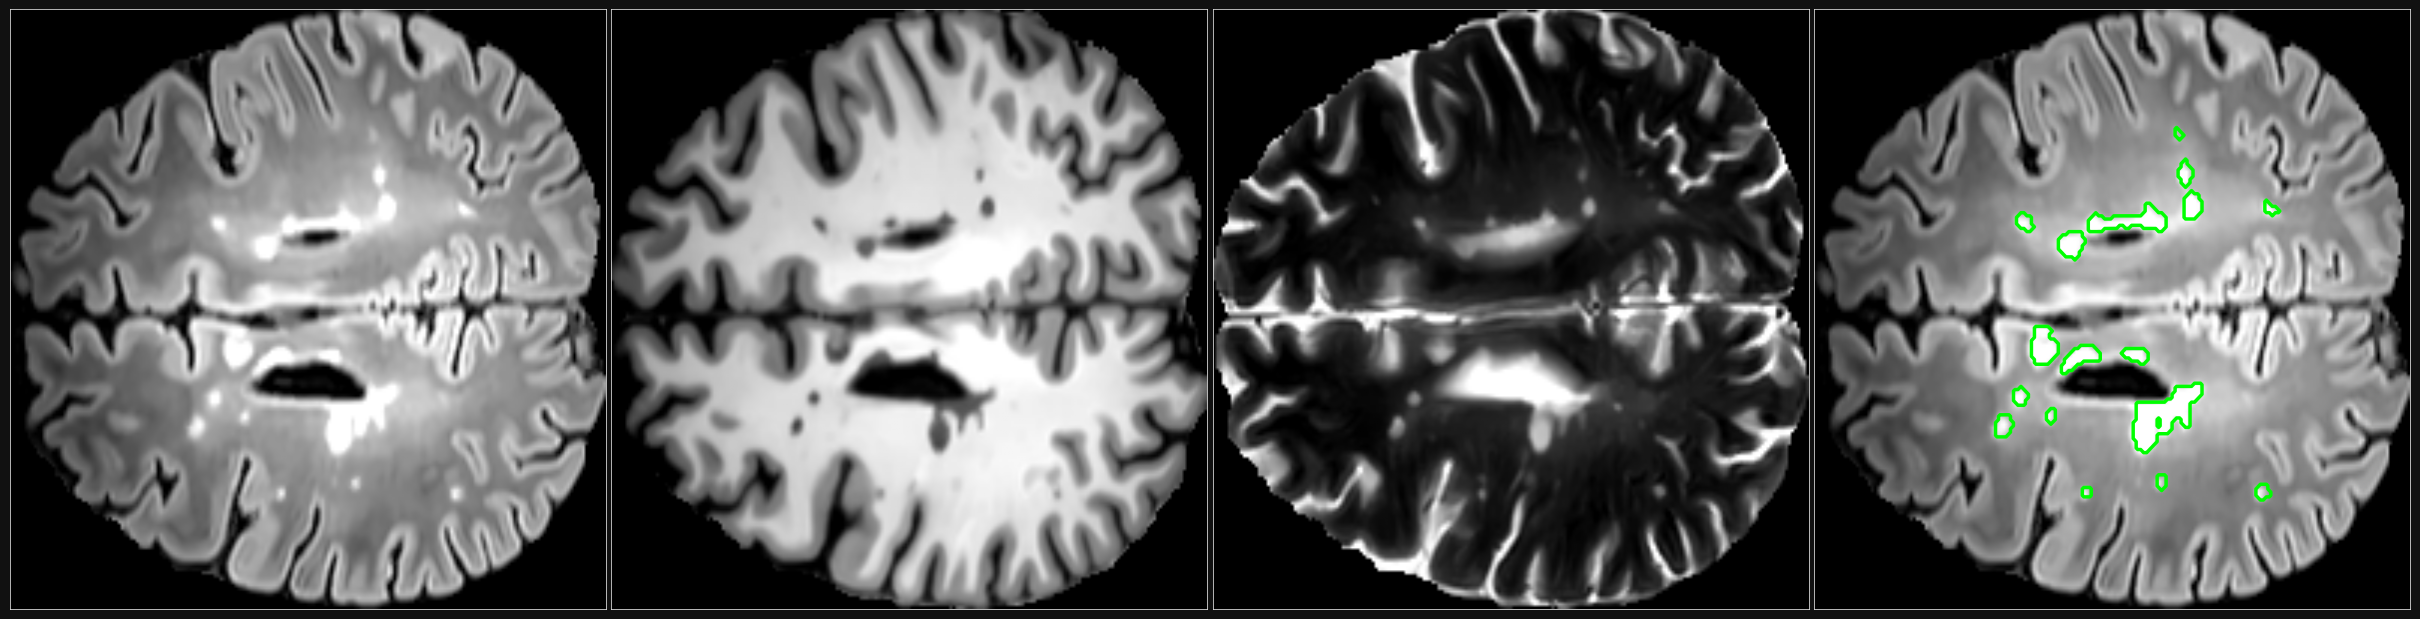

In [6]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

def normalize_image(img):
    img = img.astype(np.float32)
    mask = img > 0
    if np.any(mask):
        low = np.percentile(img[mask], 2)
        high = np.percentile(img[mask], 98)
        img = np.clip(img, low, high)
        img = (img - low) / (high - low + 1e-8)
    return img

def crop_brain(img, margin=0):
    mask = img > 0
    if not np.any(mask): return img, (0, img.shape[0], 0, img.shape[1])
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    y0, x0 = max(y0 - margin, 0), max(x0 - margin, 0)
    y1, x1 = min(y1 + margin, img.shape[0]), min(x1 + margin, img.shape[1])
    return img[y0:y1, x0:x1], (y0, y1, x0, x1)

def visualize_sample(sample_dict, slice_idx=None):
    data = {k: nib.load(sample_dict[k]).get_fdata() for k in ["flair", "t1", "t2", "label"]}
    if slice_idx is None:
        lesion_area = data["label"].sum(axis=(0, 1))
        slice_idx = np.argmax(lesion_area) if lesion_area.max() > 0 else data["label"].shape[2] // 2

    slices = {k: data[k][:, :, slice_idx] for k in data}
    for k in ["flair", "t1", "t2"]: slices[k] = normalize_image(slices[k])
    _, bbox = crop_brain(slices["flair"])
    y0, y1, x0, x1 = bbox
    for k in slices: slices[k] = slices[k][y0:y1, x0:x1]

    fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=100, facecolor='#111111')

    panels = [
        (slices["flair"], "gray", None),
        (slices["t1"], "gray", None),
        (slices["t2"], "gray", None),
        (slices["flair"], "gray", slices["label"])
    ]

    for i, (img, cmap, lbl) in enumerate(panels):
        ax = axes[i]
        ax.imshow(img, cmap=cmap, aspect='auto', interpolation='bilinear', origin='lower')

        if lbl is not None:
            ax.contour(lbl, levels=[0.5], colors='lime', linewidths=2.5, origin='lower')

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('white')
            spine.set_linewidth(0.5)

        ax.set_xticks([])
        ax.set_yticks([])

    plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0.01)
    plt.show()

if 'train_files' in globals() and train_files:
    visualize_sample(train_files[0])

## Model Architecture (Tri-Encoder with Deep Supervision)

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class ConvBlock3D(nn.Module):
    def __init__(self, input_channels, output_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv3d(input_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(output_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(output_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(output_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout3d(p=dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class AttentionGate3D(nn.Module):
    def __init__(self, gating_channels, skip_channels, intermediate_channels):
        super().__init__()
        self.W_gating = nn.Sequential(
            nn.Conv3d(gating_channels, intermediate_channels, kernel_size=1, bias=False),
            nn.InstanceNorm3d(intermediate_channels, affine=True),
        )
        self.W_skip = nn.Sequential(
            nn.Conv3d(skip_channels, intermediate_channels, kernel_size=1, bias=False),
            nn.InstanceNorm3d(intermediate_channels, affine=True),
        )
        self.attention_filter = nn.Sequential(
            nn.Conv3d(intermediate_channels, 1, kernel_size=1, bias=True),
            nn.Sigmoid(),
        )
        self.relu = nn.LeakyReLU(0.01, inplace=True)

    def forward(self, gating_signal, skip_connection):
        relevance_map = self.relu(self.W_gating(gating_signal) + self.W_skip(skip_connection))
        attention_coefficients = self.attention_filter(relevance_map)
        gated_skip = skip_connection * attention_coefficients
        # NOVELTY (explainability): return the raw coefficient map too, instead of discarding it
        return gated_skip, attention_coefficients


class ModalityGate3D(nn.Module):
    """
    NOVELTY (modality-adaptive fusion): SE-style gate that learns per-sample,
    per-modality reliability weights instead of trusting FLAIR/T1/T2 equally
    via plain concatenation. Softmax over modalities -> each branch's features
    are rescaled by how much the network currently trusts that modality.
    """
    def __init__(self, num_modalities, channels_per_modality, reduction=4):
        super().__init__()
        total_channels = num_modalities * channels_per_modality
        self.num_modalities = num_modalities
        self.pool = nn.AdaptiveAvgPool3d(1)
        hidden = max(total_channels // reduction, num_modalities)
        self.mlp = nn.Sequential(
            nn.Linear(total_channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_modalities),
        )
        self.softmax = nn.Softmax(dim=1)

    def forward(self, modality_features):
        # modality_features: list of [B, C, D, H, W] tensors, one per modality
        b = modality_features[0].shape[0]
        stacked = torch.cat(modality_features, dim=1)
        pooled = self.pool(stacked).view(b, -1)
        weights = self.softmax(self.mlp(pooled))  # [B, num_modalities]

        gated = []
        for i, feat in enumerate(modality_features):
            w = weights[:, i].view(b, 1, 1, 1, 1)
            gated.append(feat * w)
        return gated, weights


class TriEncoderAttentionUNet3D(nn.Module):
    def __init__(self, dropout=0.25, modality_dropout_p=0.15):
        super().__init__()
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)
        self.modality_dropout_p = modality_dropout_p  # NOVELTY (robustness)

        self.flair_l1 = ConvBlock3D(1, 16, dropout=0.0)
        self.t1_l1 = ConvBlock3D(1, 16, dropout=0.0)
        self.t2_l1 = ConvBlock3D(1, 16, dropout=0.0)

        self.flair_level_2 = ConvBlock3D(16, 32, dropout=dropout)
        self.t1_level_2 = ConvBlock3D(16, 32, dropout=dropout)
        self.t2_level_2 = ConvBlock3D(16, 32, dropout=dropout)

        # NOVELTY: modality-adaptive gates before fusion, one per resolution level
        self.modality_gate_l1 = ModalityGate3D(num_modalities=3, channels_per_modality=16)
        self.modality_gate_l2 = ModalityGate3D(num_modalities=3, channels_per_modality=32)

        self.fuse_l1 = ConvBlock3D(48, 32, dropout=dropout)
        self.fuse_level_2 = ConvBlock3D(96, 64, dropout=dropout)
        self.joint_l3 = ConvBlock3D(64, 128, dropout=dropout)

        self.bottleneck = ConvBlock3D(128, 256, dropout=dropout * 2)

        self.up3 = nn.ConvTranspose3d(256, 128, kernel_size=2, stride=2)
        self.att3 = AttentionGate3D(128, 128, 64)
        self.dec3 = ConvBlock3D(256, 128, dropout=dropout)

        self.up2 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.att2 = AttentionGate3D(64, 64, 32)
        self.dec2 = ConvBlock3D(128, 64, dropout=dropout)

        self.up1 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.att1 = AttentionGate3D(32, 32, 16)
        self.dec1 = ConvBlock3D(64, 32, dropout=dropout)

        self.final = nn.Conv3d(32, 1, kernel_size=1)
        self.aux3 = nn.Conv3d(128, 1, kernel_size=1)
        self.aux2 = nn.Conv3d(64, 1, kernel_size=1)

    def _apply_modality_dropout(self, flair, t1, t2):
        """
        NOVELTY (robustness): randomly zero out one whole modality per training
        sample so the model learns to still segment reasonably with a missing
        or corrupted scan. No-op at eval time (self.training == False).
        """
        if not self.training or self.modality_dropout_p <= 0:
            return flair, t1, t2

        b = flair.shape[0]
        drop_mask = torch.rand(b, 3, device=flair.device) < self.modality_dropout_p

        # never drop all 3 modalities for a sample -- keep at least one alive
        all_dropped = drop_mask.all(dim=1)
        if all_dropped.any():
            keep_idx = torch.randint(0, 3, (int(all_dropped.sum()),), device=flair.device)
            drop_mask[all_dropped, keep_idx] = False

        keep_flair = (~drop_mask[:, 0]).float().view(b, 1, 1, 1, 1)
        keep_t1 = (~drop_mask[:, 1]).float().view(b, 1, 1, 1, 1)
        keep_t2 = (~drop_mask[:, 2]).float().view(b, 1, 1, 1, 1)
        return flair * keep_flair, t1 * keep_t1, t2 * keep_t2

    def forward(self, x, return_aux=True, return_attention=False):
        flair_input = x[:, 0:1]
        t1_input = x[:, 1:2]
        t2_input = x[:, 2:3]

        flair_input, t1_input, t2_input = self._apply_modality_dropout(flair_input, t1_input, t2_input)

        f1 = self.flair_l1(flair_input)
        t1_1 = self.t1_l1(t1_input)
        t2_1 = self.t2_l1(t2_input)
        [f1_g, t1_1_g, t2_1_g], modality_weights_l1 = self.modality_gate_l1([f1, t1_1, t2_1])
        fused_skip_l1 = self.fuse_l1(torch.cat([f1_g, t1_1_g, t2_1_g], dim=1))

        f2 = self.flair_level_2(self.pool(f1))
        t1_2 = self.t1_level_2(self.pool(t1_1))
        t2_2 = self.t2_level_2(self.pool(t2_1))
        [f2_g, t1_2_g, t2_2_g], modality_weights_l2 = self.modality_gate_l2([f2, t1_2, t2_2])
        fused_skip_l2 = self.fuse_level_2(torch.cat([f2_g, t1_2_g, t2_2_g], dim=1))

        fused_f3 = self.joint_l3(self.pool(fused_skip_l2))
        bottle = self.bottleneck(self.pool(fused_f3))

        up_l3 = self.up3(bottle)
        att3_out, att3_map = self.att3(up_l3, fused_f3)
        dec_l3 = self.dec3(torch.cat([up_l3, att3_out], dim=1))

        up_l2 = self.up2(dec_l3)
        att2_out, att2_map = self.att2(up_l2, fused_skip_l2)
        dec_l2 = self.dec2(torch.cat([up_l2, att2_out], dim=1))

        up_l1 = self.up1(dec_l2)
        att1_out, att1_map = self.att1(up_l1, fused_skip_l1)
        dec_l1 = self.dec1(torch.cat([up_l1, att1_out], dim=1))

        out_final = self.final(dec_l1)

        o3 = o2 = None
        if return_aux:
            o3 = F.interpolate(self.aux3(dec_l3), size=out_final.shape[2:], mode="trilinear", align_corners=False)
            o2 = F.interpolate(self.aux2(dec_l2), size=out_final.shape[2:], mode="trilinear", align_corners=False)

        if return_attention:
            attention_maps = {"att1": att1_map, "att2": att2_map, "att3": att3_map}
            modality_weights = {"level1": modality_weights_l1, "level2": modality_weights_l2}
            if return_aux:
                return out_final, o3, o2, attention_maps, modality_weights
            return out_final, attention_maps, modality_weights

        if return_aux:
            return out_final, o3, o2
        return out_final


model = TriEncoderAttentionUNet3D(dropout=0.10).to(device)

## Loss function

In [8]:
from monai.losses import DiceFocalLoss

class DeepSupervisedDiceFocalLoss(nn.Module):
    def __init__(self, lambda_dice=0.7, lambda_focal=0.3):
        super().__init__()
        self.base_loss = DiceFocalLoss(
            sigmoid=True,
            squared_pred=True,
            lambda_dice=lambda_dice,
            lambda_focal=lambda_focal
        )
        self.aux_weights = [1.0, 0.3, 0.15]

    def forward(self, logits_list, targets):
        loss = 0.0
        for i, logits in enumerate(logits_list):
            w = self.aux_weights[i]
            if logits.shape[2:] != targets.shape[2:]:
                logits = F.interpolate(logits, size=targets.shape[2:], mode="trilinear", align_corners=False)
            loss += w * self.base_loss(logits, targets)
        normalizer = sum(self.aux_weights[:len(logits_list)])
        return loss / normalizer

criterion = DeepSupervisedDiceFocalLoss(lambda_dice=0.7, lambda_focal=0.3)

## Training Loop

In [9]:
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import math
import csv
import os

# --- T4-specific setup ---
torch.backends.cudnn.benchmark = True
AMP_DTYPE = torch.float16

max_epochs = 300
roi_size = (96, 96, 96)
sw_batch_size = 2
accumulation_steps = 2
weight_path = "best_tri_encoder_msseg_only.pth"
VAL_EVERY = 2
VAL_OVERLAP = 0.25
PRINT_EVERY = 20
log_csv_path = "training_metrics_log.csv"

# Higher peak learning rate for fast convergence
max_lr = 1e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=1e-4)

steps_per_epoch = math.ceil(len(train_loader) / accumulation_steps)
total_steps = steps_per_epoch * max_epochs

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=max_lr,
    total_steps=total_steps,
    pct_start=(10.0 / max_epochs),
    div_factor=10.0,
    final_div_factor=100.0
)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

dice_metric = DiceMetric(include_background=False, reduction="mean")
post_pred = AsDiscrete(threshold=0.5)

history_train_loss = []
history_train_acc = []
history_val_loss = []
history_val_dice = []
history_val_acc = []
best_metric = -1
scheduler_steps_taken = 0

if not os.path.exists(log_csv_path):
    with open(log_csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "train_loss", "train_acc", "val_loss", "val_dice", "val_acc", "lr"])


def predict_fn(inputs, overlap=0.5):
    return sliding_window_inference(
        inputs=inputs, roi_size=roi_size, sw_batch_size=sw_batch_size,
        predictor=lambda x: model(x, return_aux=False), overlap=overlap, mode="gaussian",
    )


def run_validation(overlap=VAL_OVERLAP):
    model.eval()
    dice_metric.reset()
    val_loss_total = 0.0
    correct_voxels = 0
    total_voxels = 0

    with torch.no_grad():
        for val_data in val_loader:
            val_inputs = val_data["image"].to(device, non_blocking=True)
            val_labels = val_data["label"].to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=(device.type == "cuda")):
                val_logits = predict_fn(val_inputs, overlap=overlap)
                val_loss_total += criterion((val_logits,), val_labels).item()
            val_probs = torch.sigmoid(val_logits)
            val_outputs_discrete = [post_pred(i) for i in val_probs]
            dice_metric(y_pred=val_outputs_discrete, y=val_labels)

            preds_stacked = torch.stack(val_outputs_discrete)
            correct_voxels += (preds_stacked == val_labels).sum().item()
            total_voxels += val_labels.numel()

    avg_dice = dice_metric.aggregate().item()
    avg_val_loss = val_loss_total / max(len(val_loader), 1)
    avg_val_acc = correct_voxels / max(total_voxels, 1)
    dice_metric.reset()
    return avg_val_loss, avg_dice, avg_val_acc


def log_to_csv(epoch, train_loss, train_acc, val_loss, val_dice, val_acc, lr):
    with open(log_csv_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch, f"{train_loss:.6f}", f"{train_acc:.6f}", f"{val_loss:.6f}",
                          f"{val_dice:.6f}", f"{val_acc:.6f}", f"{lr:.8e}"])


for epoch in range(max_epochs):
    model.train()
    epoch_loss = torch.zeros(1, device=device)
    correct_voxels_train = 0
    total_voxels_train = 0
    optimizer.zero_grad(set_to_none=True)

    for step, batch_data in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", leave=False)):
        inputs = batch_data["image"].to(device, non_blocking=True)
        labels = batch_data["label"].to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=(device.type == "cuda")):
            logits_final, logits_aux3, logits_aux2 = model(inputs, return_aux=True)
            loss = criterion((logits_final, logits_aux3, logits_aux2), labels) / accumulation_steps

        scaler.scale(loss).backward()

        if (step + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=12.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            if scheduler_steps_taken < total_steps:
                scheduler.step()
                scheduler_steps_taken += 1

        epoch_loss += loss.detach() * accumulation_steps

        with torch.no_grad():
            train_preds = (torch.sigmoid(logits_final.detach()) > 0.5).float()
            correct_voxels_train += (train_preds == labels).sum().item()
            total_voxels_train += labels.numel()

    epoch_loss = (epoch_loss / max(step + 1, 1)).item()
    epoch_train_acc = correct_voxels_train / max(total_voxels_train, 1)
    history_train_loss.append(epoch_loss)
    history_train_acc.append(epoch_train_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    # Run validation based on VAL_EVERY
    run_val = ((epoch + 1) % VAL_EVERY == 0) or epoch == 0 or (epoch + 1) == max_epochs

    if run_val:
        avg_val_loss, avg_val_dice, avg_val_acc = run_validation()
        history_val_loss.append(avg_val_loss)
        history_val_dice.append(avg_val_dice)
        history_val_acc.append(avg_val_acc)

        if avg_val_dice > best_metric:
            best_metric = avg_val_dice
            torch.save(model.state_dict(), weight_path)
    else:
        # Ensure lists are aligned even on non-validation epochs
        avg_val_loss = history_val_loss[-1] if history_val_loss else 0.0
        avg_val_dice = history_val_dice[-1] if history_val_dice else 0.0
        avg_val_acc = history_val_acc[-1] if history_val_acc else 0.0

    # Log every single epoch to the CSV
    log_to_csv(epoch + 1, epoch_loss, epoch_train_acc, avg_val_loss, avg_val_dice, avg_val_acc, current_lr)

    # Print progress every 20 epochs (or first / last epoch)
    is_print_epoch = ((epoch + 1) % PRINT_EVERY == 0) or epoch == 0 or (epoch + 1) == max_epochs
    if is_print_epoch:
        print(f"Epoch [{epoch+1}/{max_epochs}]  Train Loss: {epoch_loss:.4f}  Train Acc: {epoch_train_acc:.4f}  "
              f"Val Loss: {avg_val_loss:.4f}  Val Dice: {avg_val_dice:.4f}  "
              f"Val Acc: {avg_val_acc:.4f}  LR: {current_lr:.2e}")

print(f"Training complete. Best Val Dice: {best_metric:.4f}")
print(f"Metrics logged to {log_csv_path}")

Epoch 1/300:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [1/300]  Train Loss: 0.6883  Train Acc: 0.9049  Val Loss: 0.7232  Val Dice: 0.0079  Val Acc: 0.9485  LR: 1.23e-05


Epoch 2/300:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 3/300:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 4/300:   0%|          | 0/12 [00:00<?, ?it/s]

...

Epoch 297/300:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 298/300:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 299/300:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 300/300:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [300/300]  Train Loss: 0.2466  Train Acc: 0.9944  Val Loss: 0.5346  Val Dice: 0.7123  Val Acc: 0.9991  LR: 1.00e-07
Training complete. Best Val Dice: 0.7234
Metrics logged to training_metrics_log.csv


## Final Test Evaluation

In [22]:
weight_path = "/content/best_tri_encoder_msseg_only.pth"
model.load_state_dict(torch.load(weight_path, map_location=device))

<All keys matched successfully>

In [25]:
import os
import time
import glob
import torch
import numpy as np
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference
from tqdm.auto import tqdm

cache_dir = "eval_cache"
os.makedirs(cache_dir, exist_ok=True)

post_pred = AsDiscrete(threshold=0.5)
roi_size = (96, 96, 96)
sw_batch_size = 2

model.eval()
case_id_to_file = {}
total_inf_time = 0.0

# Configure DataLoader for safety (num_workers=0 to avoid exit errors)
test_loader.num_workers = 0

print("Running inference once on the test set and caching results...")
with torch.no_grad():
    for i, test_data in enumerate(tqdm(test_loader, desc="Caching Predictions")):
        inputs = test_data["image"].to(device)
        labels = test_data["label"].to(device)
        case_id = test_data.get("case_id", [f"Case_{i}"])[0]

        start_time = time.time()
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = sliding_window_inference(
                inputs, roi_size, sw_batch_size,
                lambda x: model(x, return_aux=False), overlap=0.5, mode="gaussian"
            )
        inf_time = time.time() - start_time
        total_inf_time += inf_time

        probs = torch.sigmoid(logits).cpu()
        preds = post_pred(probs).cpu()

        save_path = os.path.join(cache_dir, f"case_{i:03d}.pt")
        torch.save({
            "case_id": case_id,
            "probs": probs,
            "preds": preds,
            "labels": labels.cpu(),
            "flair": inputs[0, 0].cpu(),
            "image_meta": test_data.get("image_meta_dict", {}),
            "label_meta": test_data.get("label_meta_dict", {}),
            "inf_time": inf_time,
        }, save_path)
        case_id_to_file[case_id] = save_path

cache_files = sorted(glob.glob(os.path.join(cache_dir, "case_*.pt")))
print(f"Cached {len(cache_files)} cases in '{cache_dir}/'. Total inference time: {total_inf_time:.2f}s")

Running inference once on the test set and caching results...


Caching Predictions:   0%|          | 0/38 [00:00<?, ?it/s]

Cached 38 cases in 'eval_cache/'. Total inference time: 20.38s


## evaluation for each case

In [26]:
import os
import glob
import pandas as pd
import torch
import numpy as np
import warnings
from tqdm.auto import tqdm
from monai.metrics import DiceMetric, ConfusionMatrixMetric, HausdorffDistanceMetric, get_confusion_matrix

# Hide specific warnings
warnings.filterwarnings("ignore", message=".*always_return_as_numpy.*")
warnings.filterwarnings("ignore", message=".*the ground truth of class 0 is all 0.*")

# Metrics for individual case calculation - Using reduction='none' and computing on CPU for stability
dice_metric = DiceMetric(include_background=False, reduction="none")
conf_metric = ConfusionMatrixMetric(include_background=False, metric_name=["precision", "recall", "accuracy"], reduction="none")
hd95_metric = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="none")

results = []

with torch.no_grad():
    for cache_path in tqdm(sorted(glob.glob(os.path.join(cache_dir, "case_*.pt"))), desc="Per-case Metrics"):
        cached = torch.load(cache_path, map_location="cpu", weights_only=False)
        test_outputs_discrete = cached["preds"]
        test_labels_cpu = cached["labels"]
        case_id = cached["case_id"]
        inf_time = cached["inf_time"]

        # Per-case Metrics calculation
        dice_metric(y_pred=test_outputs_discrete, y=test_labels_cpu)
        conf_metric(y_pred=test_outputs_discrete, y=test_labels_cpu)
        hd95_metric(y_pred=test_outputs_discrete, y=test_labels_cpu)

        # Get Confusion Matrix Raw Values (TP, FP, TN, FN)
        conf_m = get_confusion_matrix(y_pred=test_outputs_discrete, y=test_labels_cpu)
        tp = conf_m[..., 0].item()
        fp = conf_m[..., 1].item()
        tn = conf_m[..., 2].item()
        fn = conf_m[..., 3].item()

        # Aggregate and Extract (each metric contains only 1 case because we reset below)
        dice_val = dice_metric.aggregate().item()
        c_res = conf_metric.aggregate()
        prec = c_res[0].item()
        sens = c_res[1].item()
        acc = c_res[2].item()
        hd95_val = hd95_metric.aggregate().item()

        gt_vol = torch.sum(test_labels_cpu).item()

        results.append({
            "Case ID": case_id,
            "Dice": round(dice_val, 4),
            "Accuracy": round(acc, 6),
            "Precision": round(prec, 4),
            "Sensitivity": round(sens, 4),
            "HD95 (mm)": round(hd95_val, 3),
            "TP": int(tp),
            "FP": int(fp),
            "TN": int(tn),
            "FN": int(fn),
            "Lesion Vol (vx)": int(gt_vol),
            "Inf Time (s)": round(inf_time, 2)
        })

        # IMPORTANT: Reset metrics for the next iteration
        dice_metric.reset()
        conf_metric.reset()
        hd95_metric.reset()

# Display Table
df_final_results = pd.DataFrame(results)
display(df_final_results)

print(f"\n--- AGGREGATE SUMMARY ---")
print(f"Mean Dice: {df_final_results['Dice'].mean():.4f}")
print(f"Mean HD95: {df_final_results['HD95 (mm)'].mean():.3f} mm")

Per-case Metrics:   0%|          | 0/38 [00:00<?, ?it/s]

,Case ID,Dice,Accuracy,Precision,Sensitivity,HD95 (mm),TP,FP,TN,FN,Lesion Vol (vx),Inf Time (s)
0,MSSEG_TEST_Center_01_Patient_01,0.4819,0.999833,0.3750,0.6742,25.842,240,400,3089164,116,356,0.46
1,MSSEG_TEST_Center_01_Patient_02,0.8350,0.997493,0.8479,0.8224,1.414,20114,3607,3143727,4344,24458,0.41
2,MSSEG_TEST_Center_01_Patient_03,0.8013,0.998843,0.8981,0.7232,4.472,7942,901,3392568,3039,10981,0.41
3,MSSEG_TEST_Center_01_Patient_04,0.8518,0.996829,0.8016,0.9086,1.414,31647,7832,3430948,3183,34830,0.88
4,MSSEG_TEST_Center_01_Patient_05,0.7909,0.998379,0.9116,0.6984,7.483,10995,1066,3570781,4748,15743,0.88
5,MSSEG_TEST_Center_01_Patient_06,0.6748,0.994867,0.8610,0.5548,10.488,16792,2712,3120172,13474,30266,0.42
6,MSSEG_TEST_Center_01_Patient_07,0.6579,0.999259,0.8378,0.5415,6.481,2490,482,3488900,2108,4598,0.42
7,MSSEG_TEST_Center_01_Patient_08,0.7917,0.997143,0.9052,0.7035,7.141,15069,1579,2752760,6352,21421,0.42
8,MSSEG_TEST_Center_01_Patient_09,0.6375,0.999842,0.6131,0.6639,54.162,401,253,2885983,203,604,0.43
9,MSSEG_TEST_Center_01_Patient_10,0.7441,0.999276,0.8898,0.6394,4.472,3303,409,3132767,1863,5166,0.43



--- AGGREGATE SUMMARY ---
Mean Dice: 0.6854
Mean HD95: 17.961 mm


## Average results on test dataset

In [27]:
import pandas as pd

# Update column names to English
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Define the columns for which to calculate summary statistics
columns_to_summarize = ['Dice', 'Accuracy', 'Precision', 'Sensitivity', 'HD95 (mm)']

# Calculate mean and standard deviation for the selected columns
summary_stats = df_final_results[columns_to_summarize].agg(['mean', 'std']).T
summary_stats.columns = ['Mean', 'Std'] # Rename columns as requested

display(summary_stats)

,Mean,Std
Dice,0.6854,0.1529
Accuracy,0.9983,0.0017
Precision,0.7017,0.2534
Sensitivity,0.7171,0.1317
HD95 (mm),17.9605,19.9371


In [30]:
import os
import glob
import numpy as np
import pandas as pd
import torch
from scipy.ndimage import label
from tqdm.auto import tqdm

lesion_results = []

print("Computing Lesion-wise Evaluation from cache (38 cases)...")

for cache_path in tqdm(sorted(glob.glob(os.path.join(cache_dir, "case_*.pt"))), desc="Lesion Evaluation"):
    cached = torch.load(cache_path, map_location="cpu", weights_only=False)
    labels = cached["labels"].numpy().squeeze()  # [D, H, W]
    preds = cached["preds"].numpy().squeeze()
    case_id = cached["case_id"]

    # 1. Connected Components for Lesions
    gt_labels, n_gt = label(labels)
    pred_labels, n_pred = label(preds)

    # 2. Match lesions
    # Lesion-wise TP (Sens side): How many GT lesions were hit by predictions?
    lw_tp_sens = 0
    for g in range(1, n_gt + 1):
        gt_mask = (gt_labels == g)
        if np.any(preds[gt_mask] > 0):
            lw_tp_sens += 1

    # Lesion-wise TP (Prec side): How many Pred lesions hit at least one GT?
    lw_tp_prec = 0
    for p in range(1, n_pred + 1):
        pred_mask = (pred_labels == p)
        if np.any(labels[pred_mask] > 0):
            lw_tp_prec += 1

    # 3. Calculate Derived Metrics
    lw_fn = n_gt - lw_tp_sens
    lw_fp = n_pred - lw_tp_prec

    precision = lw_tp_prec / n_pred if n_pred > 0 else (1.0 if n_gt == 0 else 0.0)
    sensitivity = lw_tp_sens / n_gt if n_gt > 0 else (1.0 if n_pred == 0 else 0.0)
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0

    lesion_results.append({
        "Case ID": case_id,
        "GT Lesions": n_gt,
        "Pred Lesions": n_pred,
        "LW TP (Sens)": lw_tp_sens,
        "LW TP (Prec)": lw_tp_prec,
        "LW FP": lw_fp,
        "LW FN": lw_fn,
        "LW Precision": round(precision, 4),
        "LW Sensitivity": round(sensitivity, 4),
        "LW F1": round(f1, 4)
    })

# Create DataFrame
df_lesion_wise = pd.DataFrame(lesion_results)

# Display overall summary
print("\n--- LESION-WISE AGGREGATE SUMMARY ---")
summary_cols = ["LW Precision", "LW Sensitivity", "LW F1"]
display(df_lesion_wise[summary_cols].mean().to_frame("Mean Across 38 Cases"))

# Display full table
display(df_lesion_wise)

Computing Lesion-wise Evaluation from cache (38 cases)...


Lesion Evaluation:   0%|          | 0/38 [00:00<?, ?it/s]


--- LESION-WISE AGGREGATE SUMMARY ---


,Mean Across 38 Cases
LW Precision,0.7004
LW Sensitivity,0.6813
LW F1,0.6476


,Case ID,GT Lesions,Pred Lesions,LW TP (Sens),LW TP (Prec),LW FP,LW FN,LW Precision,LW Sensitivity,LW F1
0,MSSEG_TEST_Center_01_Patient_01,6,13,4,4,9,2,0.3077,0.6667,0.4211
1,MSSEG_TEST_Center_01_Patient_02,47,40,38,35,5,9,0.8750,0.8085,0.8404
2,MSSEG_TEST_Center_01_Patient_03,74,56,43,55,1,31,0.9821,0.5811,0.7302
3,MSSEG_TEST_Center_01_Patient_04,70,40,26,19,21,44,0.4750,0.3714,0.4169
4,MSSEG_TEST_Center_01_Patient_05,92,88,55,82,6,37,0.9318,0.5978,0.7284
5,MSSEG_TEST_Center_01_Patient_06,205,99,65,96,3,140,0.9697,0.3171,0.4779
6,MSSEG_TEST_Center_01_Patient_07,36,33,22,28,5,14,0.8485,0.6111,0.7105
7,MSSEG_TEST_Center_01_Patient_08,95,77,62,75,2,33,0.9740,0.6526,0.7816
8,MSSEG_TEST_Center_01_Patient_09,13,16,7,7,9,6,0.4375,0.5385,0.4828
9,MSSEG_TEST_Center_01_Patient_10,39,27,19,24,3,20,0.8889,0.4872,0.6294


## Result analysis based on lesion volume

In [32]:
import os
import glob
import numpy as np
import pandas as pd
import torch
from scipy.ndimage import label
from tqdm.auto import tqdm

# Standardized thresholds for lesion sizes in mm3
# Assuming 1x1x1 mm spacing from earlier transforms, so 1 voxel = 1 mm3
SMALL_LIMIT = 50
MEDIUM_LIMIT = 500

# Initialize metrics to accumulate TPs, FPs, and FNs per size category
size_metrics = {
    "small": {"tp": 0, "fp": 0, "fn": 0, "gt_count": 0, "pred_count": 0},
    "medium": {"tp": 0, "fp": 0, "fn": 0, "gt_count": 0, "pred_count": 0},
    "large": {"tp": 0, "fp": 0, "fn": 0, "gt_count": 0, "pred_count": 0}
}

def get_size_category(volume):
    if volume < SMALL_LIMIT:
        return "small"
    if volume < MEDIUM_LIMIT:
        return "medium"
    return "large"

print("Analyzing lesion size distribution from cache with rigorous matching...")
for cache_path in tqdm(sorted(glob.glob(os.path.join(cache_dir, "case_*.pt"))), desc="Analyzing by Size"):
    cached = torch.load(cache_path, map_location="cpu", weights_only=False)
    labels = cached["labels"].numpy().squeeze()
    preds = cached["preds"].numpy().squeeze()

    gt_labels, n_gt = label(labels)
    pred_labels, n_pred = label(preds)

    # Track which predicted labels overlap with any ground truth
    pred_hit_map = np.zeros(n_pred + 1, dtype=bool)
    # Track which GT labels are overlapped by any prediction
    gt_hit_map = np.zeros(n_gt + 1, dtype=bool)

    # Find overlaps
    if n_gt > 0 and n_pred > 0:
        # Fast overlap calculation via binning
        overlap_mask = (gt_labels > 0) & (pred_labels > 0)
        if np.any(overlap_mask):
            gt_ids = gt_labels[overlap_mask]
            pred_ids = pred_labels[overlap_mask]
            gt_hit_map[gt_ids] = True
            pred_hit_map[pred_ids] = True

    # 1. Categorize GT lesions (TP vs FN)
    for g in range(1, n_gt + 1):
        vol = np.sum(gt_labels == g)
        cat = get_size_category(vol)
        size_metrics[cat]["gt_count"] += 1
        if gt_hit_map[g]:
            size_metrics[cat]["tp"] += 1
        else:
            size_metrics[cat]["fn"] += 1

    # 2. Categorize Pred lesions (FP)
    for p in range(1, n_pred + 1):
        vol = np.sum(pred_labels == p)
        cat = get_size_category(vol)
        size_metrics[cat]["pred_count"] += 1
        if not pred_hit_map[p]:
            size_metrics[cat]["fp"] += 1

# Finalizing calculations
summary_rows = []
for cat in ["small", "medium", "large"]:
    tp = size_metrics[cat]["tp"]
    fp = size_metrics[cat]["fp"]
    fn = size_metrics[cat]["fn"]
    gt = size_metrics[cat]["gt_count"]
    pred = size_metrics[cat]["pred_count"]

    # Precision: Out of all predictions of this size, how many hit a ground truth?
    # We calculate it as (Total Predictions - False Predictions) / Total Predictions
    hits = pred - fp
    precision = hits / pred if pred > 0 else (1.0 if gt == 0 else 0.0)

    # Sensitivity: Out of all GT lesions of this size, how many were detected?
    sensitivity = tp / gt if gt > 0 else (1.0 if pred == 0 else 0.0)

    # F1-Score: Harmonic mean of our precise precision and sensitivity
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0

    summary_rows.append({
        "Lesion Size": cat,
        "Total GT": gt,
        "Detected (TP)": tp,
        "Missed (FN)": fn,
        "False Alarms (FP)": fp,
        "Precision": round(precision, 4),
        "Sensitivity": round(sensitivity, 4),
        "F1-Score": round(f1, 4)
    })

df_size_analysis = pd.DataFrame(summary_rows)
display(df_size_analysis)

Analyzing lesion size distribution from cache with rigorous matching...


Analyzing by Size:   0%|          | 0/38 [00:00<?, ?it/s]

,Lesion Size,Total GT,Detected (TP),Missed (FN),False Alarms (FP),Precision,Sensitivity,F1-Score
0,small,1243,543,700,314,0.7038,0.4368,0.5391
1,medium,591,522,69,59,0.8913,0.8832,0.8873
2,large,97,96,1,4,0.9633,0.9897,0.9763


In [33]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.transforms import SaveImage
from tqdm.auto import tqdm

# Create output directory
output_dir = "msseg_predictions"
os.makedirs(output_dir, exist_ok=True)

# Initialize SaveImage transforms
# We disable resampling to keep original header info
save_prob = SaveImage(output_dir=output_dir, output_postfix="prob", output_ext=".nii.gz", resample=False, separate_folder=False)
save_bin = SaveImage(output_dir=output_dir, output_postfix="mask", output_ext=".nii.gz", resample=False, separate_folder=False)
save_gt = SaveImage(output_dir=output_dir, output_postfix="gt", output_ext=".nii.gz", resample=False, separate_folder=False)

print(f"Saving predictions for 38 cases to '{output_dir}'...")

for cache_path in tqdm(sorted(glob.glob(os.path.join(cache_dir, "case_*.pt"))), desc="Saving NIfTI & Overlays"):
    cached = torch.load(cache_path, map_location="cpu", weights_only=False)
    probs = cached["probs"]
    binary_mask = cached["preds"]
    labels = cached["labels"]
    flair = cached["flair"]
    case_id = cached["case_id"]

    # 1. Save NIfTI files
    img_meta = cached.get("image_meta", {})
    label_meta = cached.get("label_meta", {})

    save_prob(probs[0], meta_data=img_meta)
    save_bin(binary_mask[0], meta_data=img_meta)
    save_gt(labels[0], meta_data=label_meta)

    # 2. Generate Overlay Visualization for the case
    gt_np = labels[0, 0].numpy()
    pred_np = binary_mask[0, 0].numpy()
    flair_np = flair.numpy()

    # Find slice with maximum ground truth lesion area
    slice_idx = np.argmax(np.sum(gt_np, axis=(0, 1)))

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(flair_np[:, :, slice_idx], cmap="gray", origin="lower")

    # Ground Truth in Lime Green
    if np.any(gt_np[:, :, slice_idx]):
        ax.contour(gt_np[:, :, slice_idx], levels=[0.5], colors="lime", linewidths=1.5)

    # Prediction in Dashed Red
    if np.any(pred_np[:, :, slice_idx]):
        ax.contour(pred_np[:, :, slice_idx], levels=[0.5], colors="red", linewidths=1.5, linestyles="dashed")

    ax.set_title(f"Overlay: {case_id} (Green=GT, Red=Pred)")
    ax.axis("off")

    plt.savefig(os.path.join(output_dir, f"{case_id}_overlay.png"), bbox_inches='tight')
    plt.close(fig)

print(f"\nAll files saved successfully in {output_dir}")

Saving predictions for 38 cases to 'msseg_predictions'...


Saving NIfTI & Overlays:   0%|          | 0/38 [00:00<?, ?it/s]

2026-09-22 08:41:40,324 INFO image_writer.py:197 - writing: msseg_predictions/0_prob.nii.gz
2026-09-22 08:41:40,836 INFO image_writer.py:197 - writing: msseg_predictions/0_mask.nii.gz
2026-09-22 08:41:40,912 INFO image_writer.py:197 - writing: msseg_predictions/0_gt.nii.gz
2026-09-22 08:41:41,179 INFO image_writer.py:197 - writing: msseg_predictions/1_prob.nii.gz
2026-09-22 08:41:41,699 INFO image_writer.py:197 - writing: msseg_predictions/1_mask.nii.gz
2026-09-22 08:41:41,786 INFO image_writer.py:197 - writing: msseg_predictions/1_gt.nii.gz
2026-09-22 08:41:42,073 INFO image_writer.py:197 - writing: msseg_predictions/2_prob.nii.gz
2026-09-22 08:41:42,638 INFO image_writer.py:197 - writing: msseg_predictions/2_mask.nii.gz
2026-09-22 08:41:42,738 INFO image_writer.py:197 - writing: msseg_predictions/2_gt.nii.gz
2026-09-22 08:41:43,035 INFO image_writer.py:197 - writing: msseg_predictions/3_prob.nii.gz
2026-09-22 08:41:43,644 INFO image_writer.py:197 - writing: msseg_predictions/3_mask.n

## Save model output in NIfTI

In [34]:
!zip -r /content/msseg_predictions.zip /content/msseg_predictions

  adding: content/msseg_predictions/ (stored 0%)
  adding: content/msseg_predictions/26_mask.nii.gz (deflated 64%)
  adding: content/msseg_predictions/25_prob.nii.gz (deflated 0%)
  adding: content/msseg_predictions/0_prob.nii.gz (deflated 0%)
  adding: content/msseg_predictions/9_gt.nii.gz (deflated 83%)
  adding: content/msseg_predictions/5_mask.nii.gz (deflated 61%)
  adding: content/msseg_predictions/12_prob.nii.gz (deflated 0%)
  adding: content/msseg_predictions/10_mask.nii.gz (deflated 44%)
  adding: content/msseg_predictions/MSSEG_TEST_Center_03_Patient_04_overlay.png (deflated 7%)
  adding: content/msseg_predictions/7_prob.nii.gz (deflated 0%)
  adding: content/msseg_predictions/MSSEG_TEST_Center_07_Patient_07_overlay.png (deflated 6%)
  adding: content/msseg_predictions/31_gt.nii.gz (deflated 59%)
  adding: content/msseg_predictions/14_prob.nii.gz (deflated 0%)
  adding: content/msseg_predictions/15_prob.nii.gz (deflated 0%)
  adding: content/msseg_predictions/24_mask.nii.gz 

## interpretability results

In [28]:
import os
import glob
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label
from tqdm.auto import tqdm

# 1. Identify representative cases
best_case_id = df_final_results.loc[df_final_results['Dice'].idxmax(), 'Case ID']
worst_case_id = df_final_results.loc[df_final_results['Dice'].idxmin(), 'Case ID']
avg_dice = df_final_results['Dice'].mean()
median_case_id = df_final_results.iloc[(df_final_results['Dice'] - avg_dice).abs().dropna().argsort()[:1]]['Case ID'].values[0]

# Calculate small-lesion-rich case using 3D connected components (structure of 26-connectivity)
print("Identifying small-lesion-rich case using 3D connected components...")
structure_26 = np.ones((3, 3, 3))
best_small_case_id = None
max_small_count = -1
small_case_slices = []

for cache_path in sorted(glob.glob(os.path.join(cache_dir, "case_*.pt"))):
    cached = torch.load(cache_path, map_location="cpu", weights_only=False)
    labels_np = cached["labels"].numpy().squeeze()
    case_id_tmp = cached["case_id"]

    labeled_gt, num_feats = label(labels_np, structure=structure_26)
    small_count = 0
    slices_with_small_lesion = []

    for g in range(1, num_feats + 1):
        mask = (labeled_gt == g)
        volume_mm3 = np.sum(mask)  # assuming 1x1x1 mm3 voxel size
        if 0 < volume_mm3 < 50:
            small_count += 1
            z_coords = np.where(mask)[0]
            slices_with_small_lesion.extend(list(np.unique(z_coords)))

    if small_count > max_small_count:
        max_small_count = small_count
        best_small_case_id = case_id_tmp
        small_case_slices = slices_with_small_lesion

print(f"Selected small-lesion-rich case: {best_small_case_id} with {max_small_count} lesions (<50 mm3)")

target_cases = {
    "Best": best_case_id,
    "Worst": worst_case_id,
    "Average": median_case_id,
    "Small_Lesions": best_small_case_id
}
target_ids = set(target_cases.values())

output_explain_dir = "interpretability_results"
os.makedirs(output_explain_dir, exist_ok=True)

model.eval()
print("Extracting interpretability outputs ONLY for representative cases...")

modality_weights_list = []
with torch.no_grad():
    for test_data in tqdm(test_loader, desc="Explainability Inference"):
        inputs = test_data["image"].to(device)
        case_id = test_data.get("case_id", ["Unknown"])[0]
        if case_id not in target_ids:
            continue

        # Central crop 96x96x96 forward (attention path only for the target case)
        d, h, w = inputs.shape[2:]
        crop_slice = inputs[:, :, d//2-48:d//2+48, h//2-48:h//2+48, w//2-48:w//2+48]

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            _, att_maps, weights = model(crop_slice, return_aux=False, return_attention=True)

        # Modality gate weights for this case
        mw1 = weights['level1'].cpu().numpy().mean(axis=0)
        mw2 = weights['level2'].cpu().numpy().mean(axis=0)
        modality_weights_list.append({
            "Case ID": case_id,
            "L1_FLAIR": mw1[0], "L1_T1": mw1[1], "L1_T2": mw1[2],
            "L2_FLAIR": mw2[0], "L2_T1": mw2[1], "L2_T2": mw2[2]
        })

        label_name = [k for k, v in target_cases.items() if v == case_id][0]

        # Select visualization slice index
        if label_name == "Small_Lesions":
            # Choose slice with highest concentration of small reference lesions
            unique_sl, counts_sl = np.unique(small_case_slices, return_counts=True)
            visual_slice_idx = unique_sl[np.argmax(counts_sl)]

            # Load whole-volume data from cache for correct visualization
            case_idx_str = best_small_case_id.split('_')[-1]
            matching_caches = [f for f in glob.glob(os.path.join(cache_dir, "case_*.pt")) if torch.load(f, map_location="cpu")["case_id"] == best_small_case_id]
            cached_vol = torch.load(matching_caches[0], map_location="cpu")

            flair_slice = cached_vol["flair"].numpy().squeeze()[visual_slice_idx]
            gt_slice = cached_vol["labels"].numpy().squeeze()[visual_slice_idx]
            pred_slice = cached_vol["preds"].numpy().squeeze()[visual_slice_idx]

            fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=100)
            ax.imshow(flair_slice, cmap="gray", origin="lower")
            if np.any(gt_slice):
                ax.contour(gt_slice, levels=[0.5], colors="lime", linewidths=1.5)
            if np.any(pred_slice):
                ax.contour(pred_slice, levels=[0.5], colors="red", linewidths=1.5, linestyles="dashed")
            ax.set_title(f"Small Lesion Case Study: {best_small_case_id}\n(Slice: {visual_slice_idx}, Count: {max_small_count})")
            ax.axis("off")
            plt.savefig(os.path.join(output_explain_dir, f"att_map_{label_name}.png"), bbox_inches='tight')
            plt.close(fig)
        else:
            # Default attention gate visualization
            att_data = att_maps['att1'].cpu().numpy()[0, 0]
            mid = att_data.shape[2] // 2

            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            axes[0].imshow(crop_slice[0, 0, :, :, mid].cpu().numpy(), cmap='gray')
            axes[0].set_title(f"Input - {label_name}")
            im = axes[1].imshow(att_data[:, :, mid], cmap='hot')
            axes[1].set_title("Attention Gate (L1)")
            plt.colorbar(im, ax=axes[1])
            plt.savefig(os.path.join(output_explain_dir, f"att_map_{label_name}.png"))
            plt.close(fig)

df_weights = pd.DataFrame(modality_weights_list)
df_weights.to_csv(os.path.join(output_explain_dir, "modality_weights.csv"), index=False)
display(df_weights)


Identifying small-lesion-rich case using 3D connected components...
Selected small-lesion-rich case: MSSEG_TEST_Center_01_Patient_06 with 121 lesions (<50 mm3)
Extracting interpretability outputs ONLY for representative cases...


Explainability Inference:   0%|          | 0/38 [00:00<?, ?it/s]

,Case ID,L1_FLAIR,L1_T1,L1_T2,L2_FLAIR,L2_T1,L2_T2
0,MSSEG_TEST_Center_01_Patient_06,0.4653,0.3297,0.2051,0.4552,0.2792,0.2656
1,MSSEG_TEST_Center_03_Patient_08,0.4633,0.3304,0.2063,0.4517,0.2799,0.2685
2,MSSEG_TEST_Center_08_Patient_01,0.4667,0.3291,0.2042,0.4536,0.2797,0.2668
3,MSSEG_TEST_Center_08_Patient_05,0.4607,0.3301,0.2092,0.4507,0.2803,0.2690


In [29]:
!zip -r /content/interpretability_results.zip /content/interpretability_results

  adding: content/interpretability_results/ (stored 0%)
  adding: content/interpretability_results/att_map_Best.png (deflated 2%)
  adding: content/interpretability_results/att_map_Small_Lesions.png (deflated 5%)
  adding: content/interpretability_results/modality_weights.csv (deflated 50%)
  adding: content/interpretability_results/att_map_Worst.png (deflated 2%)
  adding: content/interpretability_results/att_map_Average.png (deflated 2%)


Calculating aggregate confusion matrix from cache (38 cases)...


Aggregate Confusion Matrix:   0%|          | 0/38 [00:00<?, ?it/s]

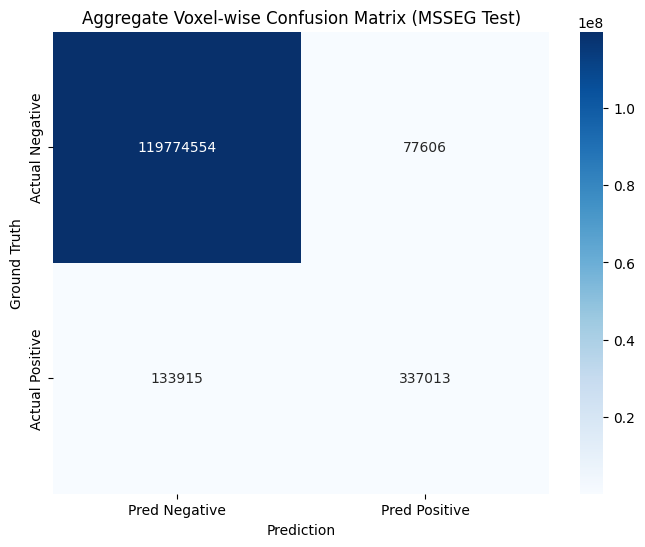

In [35]:
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from monai.metrics import get_confusion_matrix
from tqdm.auto import tqdm
import torch
import numpy as np

# Initialize counters
tp_total, fp_total, fn_total, tn_total = 0, 0, 0, 0

print("Calculating aggregate confusion matrix from cache (38 cases)...")

for cache_path in tqdm(sorted(glob.glob(os.path.join(cache_dir, "case_*.pt"))), desc="Aggregate Confusion Matrix"):
    cached = torch.load(cache_path, map_location="cpu", weights_only=False)
    preds = cached["preds"]
    labels = cached["labels"]

    # Compute confusion matrix for this sample
    conf_m = get_confusion_matrix(y_pred=preds, y=labels)

    tp_total += conf_m[..., 0].sum().item()
    fp_total += conf_m[..., 1].sum().item()
    tn_total += conf_m[..., 2].sum().item()
    fn_total += conf_m[..., 3].sum().item()

# Construct matrix for plotting: [[TN, FP], [FN, TP]]
cm_array = np.array([[tn_total, fp_total], [fn_total, tp_total]])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_array, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=['Pred Negative', 'Pred Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title("Aggregate Voxel-wise Confusion Matrix (MSSEG Test)")
plt.ylabel('Ground Truth')
plt.xlabel('Prediction')
plt.show()

## Test results table

In [36]:
import os
import glob
import pandas as pd
import numpy as np
from monai.metrics import DiceMetric, ConfusionMatrixMetric
import torch
from tqdm.auto import tqdm

dice_metric = DiceMetric(include_background=False, reduction="none")
conf_matrix = ConfusionMatrixMetric(include_background=False, metric_name=["precision", "recall"], reduction="none")

results = []

print("Building test results table from cache...")
for cache_path in tqdm(sorted(glob.glob(os.path.join(cache_dir, "case_*.pt"))), desc="Test results table"):
    cached = torch.load(cache_path, map_location="cpu", weights_only=False)
    preds = cached["preds"]
    labels = cached["labels"]
    case_id = cached["case_id"]

    # Calculate Volumes
    gt_vol = torch.sum(labels).item()
    pred_vol = torch.sum(preds).item()

    # Calculate Metrics
    dice_metric(y_pred=preds, y=labels)
    conf_matrix(y_pred=preds, y=labels)

    dice_val = dice_metric.aggregate().item()

    # Handle Empty Ground Truth cases (NaN handling)
    if gt_vol == 0:
        if pred_vol == 0:
            dice_val = 1.0  # Perfect prediction of empty case
        else:
            dice_val = 0.0  # False positive on empty case
    elif np.isnan(dice_val):
        dice_val = 0.0

    prec_rec = conf_matrix.aggregate()
    precision_val = prec_rec[0].item() if not torch.isnan(prec_rec[0]) else (1.0 if (gt_vol == 0 and pred_vol == 0) else 0.0)
    recall_val = prec_rec[1].item() if not torch.isnan(prec_rec[1]) else (1.0 if (gt_vol == 0 and pred_vol == 0) else 0.0)

    results.append({
        "Patient ID": case_id,
        "Dice": round(float(dice_val), 4),
        "Precision": round(float(precision_val), 4),
        "Recall (Sens)": round(float(recall_val), 4),
        "Ground Truth Volume (mm3)": gt_vol,
        "Pred Volume (mm3)": pred_vol
    })

    # Reset metrics for next case
    dice_metric.reset()
    conf_matrix.reset()

# Create DataFrame
df_results = pd.DataFrame(results)
# Highlight summary
display(df_results)

Building test results table from cache...


Test results table:   0%|          | 0/38 [00:00<?, ?it/s]

,Patient ID,Dice,Precision,Recall (Sens),Ground Truth Volume (mm3),Pred Volume (mm3)
0,MSSEG_TEST_Center_01_Patient_01,0.4819,0.3750,0.6742,356.0000,640.0000
1,MSSEG_TEST_Center_01_Patient_02,0.8350,0.8479,0.8224,24458.0000,23721.0000
2,MSSEG_TEST_Center_01_Patient_03,0.8013,0.8981,0.7232,10981.0000,8843.0000
3,MSSEG_TEST_Center_01_Patient_04,0.8518,0.8016,0.9086,34830.0000,39479.0000
4,MSSEG_TEST_Center_01_Patient_05,0.7909,0.9116,0.6984,15743.0000,12061.0000
5,MSSEG_TEST_Center_01_Patient_06,0.6748,0.8610,0.5548,30266.0000,19504.0000
6,MSSEG_TEST_Center_01_Patient_07,0.6579,0.8378,0.5415,4598.0000,2972.0000
7,MSSEG_TEST_Center_01_Patient_08,0.7917,0.9052,0.7035,21421.0000,16648.0000
8,MSSEG_TEST_Center_01_Patient_09,0.6375,0.6131,0.6639,604.0000,654.0000
9,MSSEG_TEST_Center_01_Patient_10,0.7441,0.8898,0.6394,5166.0000,3712.0000


## centers statistics

In [37]:
import pandas as pd

# 1. Extract Center information from the Patient IDs in the results
def extract_center(patient_id):
    parts = patient_id.split('_')
    if 'Center' in parts:
        idx = parts.index('Center')
        return f"Center_{parts[idx+1]}"
    return "Unknown"

df_results['Center'] = df_results['Patient ID'].apply(extract_center)

# 2. Analyze distribution
test_centers = df_results['Center'].unique()
val_centers = set([extract_center(f['case_id']) for f in val_files])
train_centers = set([extract_center(f['case_id']) for f in train_files])

print(f"Centers in Training: {sorted(list(train_centers))}")
print(f"Centers in Validation: {sorted(list(val_centers))}")
print(f"Centers in Test: {sorted(list(test_centers))}")

# 3. Aggregate results by Center
center_summary = df_results.groupby('Center').agg({
    'Dice': ['mean', 'std', 'count'],
    'Precision': 'mean',
    'Recall (Sens)': 'mean',
    'Ground Truth Volume (mm3)': 'mean'
}).round(4)

print("\nPerformance Summary per Center/Scanner:")
display(center_summary)

Centers in Training: ['Center_01', 'Center_07', 'Center_08']
Centers in Validation: ['Center_07', 'Center_08']
Centers in Test: ['Center_01', 'Center_03', 'Center_07', 'Center_08']

Performance Summary per Center/Scanner:


Dice              Precision Recall (Sens)  \
            mean    std count      mean          mean   
Center                                                  
Center_01 0.7267 0.1140    10    0.7941        0.6930   
Center_03 0.6422 0.1458     8    0.7197        0.6262   
Center_07 0.6308 0.2441    10    0.6054        0.7036   
Center_08 0.6649 0.2220    10    0.6912        0.7556   

          Ground Truth Volume (mm3)  
                               mean  
Center                               
Center_01                14842.3000  
Center_03                17462.1250  
Center_07                 6241.1000  
Center_08                12039.7000

## Training Curves

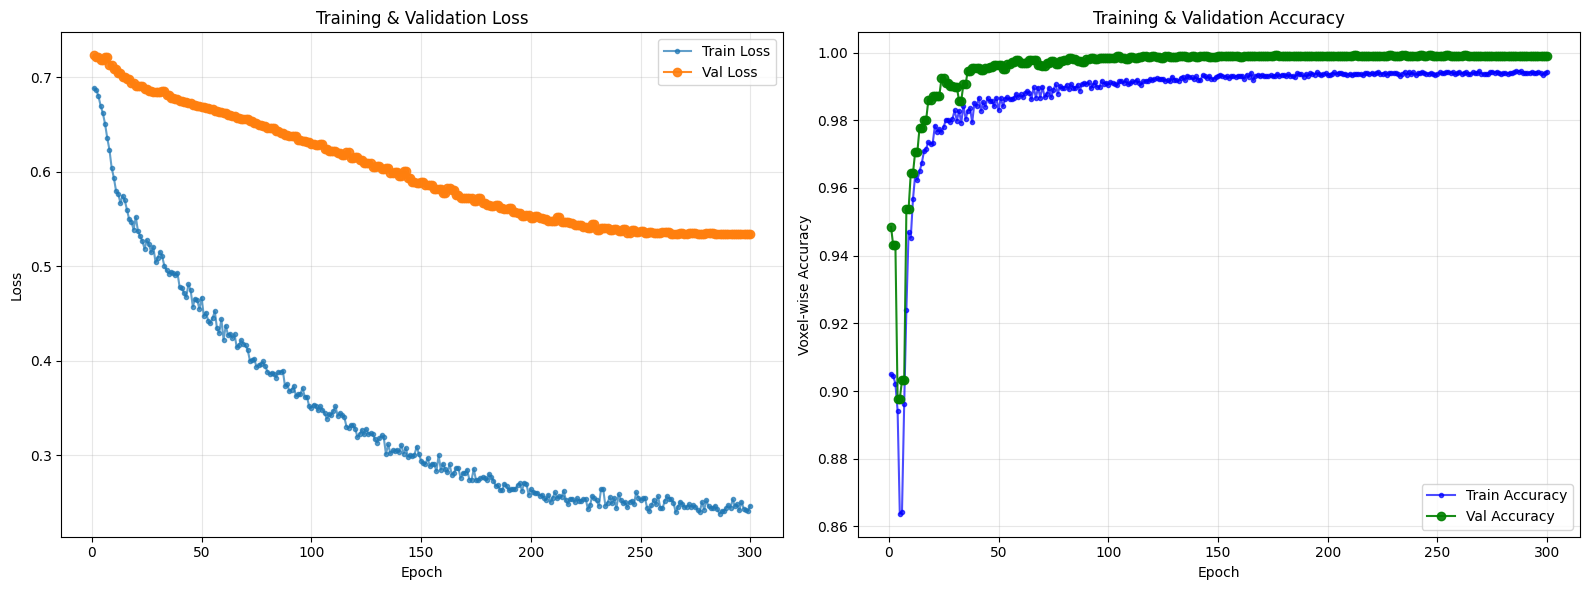

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import os

log_csv_path = "/content/training_metrics_log.csv"

if os.path.exists(log_csv_path):
    df_log = pd.read_csv(log_csv_path)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Subplot 1: Loss
    axes[0].plot(df_log["epoch"], df_log["train_loss"], label="Train Loss", marker='.', alpha=0.7)
    axes[0].plot(df_log["epoch"], df_log["val_loss"], label="Val Loss", marker='o', alpha=0.9)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training & Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Subplot 2: Accuracy (Replacing Dice)
    axes[1].plot(df_log["epoch"], df_log["train_acc"], label="Train Accuracy", color="blue", marker='.', alpha=0.7)
    axes[1].plot(df_log["epoch"], df_log["val_acc"], label="Val Accuracy", color="green", marker='o', alpha=0.9)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Voxel-wise Accuracy")
    axes[1].set_title("Training & Validation Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print(f"Log file {log_csv_path} not found. Please ensure training has started and logged data.")

## Eval test without preprocessing

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ConcatItemsd, EnsureTyped
from monai.data import Dataset, DataLoader
from monai.metrics import DiceMetric, ConfusionMatrixMetric, HausdorffDistanceMetric
from monai.inferers import sliding_window_inference

# 1. Define minimal transforms (No Spacing, No NormalizeIntensity)
raw_test_transforms = Compose([
    LoadImaged(keys=["flair", "t1", "t2", "label"]),
    EnsureChannelFirstd(keys=["flair", "t1", "t2", "label"]),
    ConcatItemsd(keys=["flair", "t1", "t2"], name="image", dim=0),
    EnsureTyped(keys=["image", "label"]),
])

raw_test_ds = Dataset(data=msseg_test_files, transform=raw_test_transforms)
raw_test_loader = DataLoader(raw_test_ds, batch_size=1, num_workers=0)

# 2. Setup Metrics
model.eval()
dice_metric = DiceMetric(include_background=False, reduction="mean")
conf_metric = ConfusionMatrixMetric(include_background=False, metric_name=["precision", "recall"], reduction="mean")
hd95_metric = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="mean", get_not_nans=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluating {len(msseg_test_files)} cases without preprocessing...")

with torch.no_grad():
    for test_data in tqdm(raw_test_loader):
        inputs = test_data["image"].to(device)
        labels = test_data["label"].to(device)
        with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            logits = sliding_window_inference(inputs, (96, 96, 96), 2, lambda x: model(x, return_aux=False), overlap=0.5)
        preds = (torch.sigmoid(logits) > 0.5).float()
        dice_metric(y_pred=preds, y=labels)
        conf_metric(y_pred=preds, y=labels)
        hd95_metric(y_pred=preds.cpu(), y=labels.cpu())

# 3. Aggregate results
raw_res = {"Dice": dice_metric.aggregate().item(), "Precision": conf_metric.aggregate()[0].item(), "Sensitivity": conf_metric.aggregate()[1].item(), "HD95": hd95_metric.aggregate().item()}
dice_metric.reset(); conf_metric.reset(); hd95_metric.reset()

# 4. Visualization
pre_res = {"Dice": summary_stats.loc["Dice", "Mean"], "Precision": summary_stats.loc["Precision", "Mean"], "Sensitivity": summary_stats.loc["Sensitivity", "Mean"], "HD95": summary_stats.loc["HD95 (mm)", "Mean"]}

plot_df = pd.DataFrame([{"Metric": k, "Score": v, "Type": "Preprocessed"} for k, v in pre_res.items()] + [{"Metric": k, "Score": v, "Type": "Raw" } for k, v in raw_res.items()])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [3, 1]})
sns.set_style("whitegrid")

# Main Plot (Ratios)
sub_df = plot_df[plot_df['Metric'] != 'HD95']
g1 = sns.barplot(data=sub_df, x="Metric", y="Score", hue="Type", palette="Blues_d", ax=ax1)
ax1.set_title("Performance Comparison (Ratios)", fontsize=14)
ax1.set_ylim(0, 1.1)
for p in g1.patches: g1.annotate(format(p.get_height(), '.3f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

# HD95 Plot
hd_df = plot_df[plot_df['Metric'] == 'HD95']
g2 = sns.barplot(data=hd_df, x="Metric", y="Score", hue="Type", palette="Reds_d", ax=ax2)
ax2.set_title("HD95 Comparison (mm)", fontsize=14)
for p in g2.patches: g2.annotate(format(p.get_height(), '.1f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.savefig("performance_comparison_preprocessing_vs_beforeProcessing.png")
plt.show()

print(f"\n--- RAW DATA EVALUATION SUMMARY ---")
for k, v in raw_res.items(): print(f"{k}: {v:.4f}")

Evaluating 38 cases without preprocessing...


  0%|          | 0/38 [00:00<?, ?it/s]

## CAD Analysis

Created 38 reports in /content/ms_cad_reports
Volume Pearson Correlation: 0.9346
Count Pearson Correlation: 0.9313
Mean lesion-wise F1 across cases: 0.6914
Saved validation plot to /content/ms_cad_reports/ms_cad_validation.png


,case_id,pred_lesion_count,pred_total_lesion_volume_mL,pred_count_small (<50mm3),pred_count_medium (50-500mm3),pred_count_large (>500mm3),gt_lesion_count,gt_total_lesion_volume_mL,lesion_TP,lesion_FP,lesion_FN,lesion_precision,lesion_recall,lesion_f1
0,MSSEG_TEST_Center_01_Patient_01,12,0.637,6,6,0,6,0.356,3,9,3,0.2500,0.5000,0.3333
1,MSSEG_TEST_Center_01_Patient_02,33,23.715,16,11,6,37,24.452,30,3,7,0.9091,0.8108,0.8571
2,MSSEG_TEST_Center_01_Patient_03,43,8.833,22,15,6,53,10.976,38,0,15,1.0000,0.7170,0.8352
3,MSSEG_TEST_Center_01_Patient_04,28,39.474,18,7,3,17,34.821,14,14,3,0.5000,0.8235,0.6222
4,MSSEG_TEST_Center_01_Patient_05,66,12.046,34,25,7,64,15.738,45,3,19,0.9375,0.7031,0.8036
5,MSSEG_TEST_Center_01_Patient_06,73,19.493,41,24,8,144,30.244,54,1,90,0.9818,0.3750,0.5427
6,MSSEG_TEST_Center_01_Patient_07,26,2.966,13,11,2,32,4.596,19,2,13,0.9048,0.5938,0.7170
7,MSSEG_TEST_Center_01_Patient_08,63,16.644,20,36,7,83,21.418,56,0,27,1.0000,0.6747,0.8058
8,MSSEG_TEST_Center_01_Patient_09,12,0.648,9,3,0,13,0.604,6,6,7,0.5000,0.4615,0.4800
9,MSSEG_TEST_Center_01_Patient_10,23,3.711,9,12,2,30,5.165,17,3,13,0.8500,0.5667,0.6800


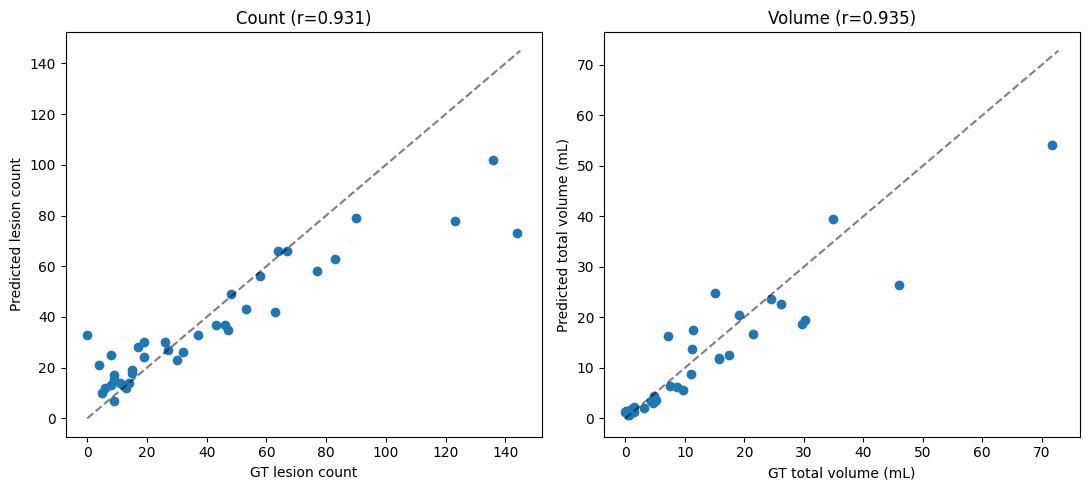

In [ ]:
import os
import glob
import math
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
from scipy import ndimage
from scipy.stats import pearsonr

# --- CONFIG ---
INPUT_MODE = "cache"
CACHE_DIR = "/content/eval_cache"
OUTPUT_DIR = "/content/ms_cad_reports"
os.makedirs(OUTPUT_DIR, exist_ok=True)

VOXEL_VOLUME_MM3 = 1.0

# Standardized thresholds: 50 and 500 mm3
SIZE_BINS_VOL_MM3 = {
    "small (<50mm3)": (0.0, 50.0),
    "medium (50-500mm3)": (50.0, 500.0),
    "large (>500mm3)": (500.0, float("inf")),
}

MIN_LESION_VOXELS = 3
CONNECTIVITY_STRUCTURE = ndimage.generate_binary_structure(3, 3)


# --- CORE FUNCTIONS ---
def classify_size_by_vol(volume_mm3):
    for label, (low, high) in SIZE_BINS_VOL_MM3.items():
        if low <= volume_mm3 < high:
            return label
    return "unclassified"


def extract_lesions(binary_mask, voxel_volume_mm3=VOXEL_VOLUME_MM3, min_voxels=MIN_LESION_VOXELS):
    binary_mask = np.asarray(binary_mask).astype(bool)
    labeled, num_features = ndimage.label(binary_mask, structure=CONNECTIVITY_STRUCTURE)
    lesions = []
    for lesion_id in range(1, num_features + 1):
        voxel_count = int(np.sum(labeled == lesion_id))
        if voxel_count < min_voxels:
            labeled[labeled == lesion_id] = 0
            continue
        vol_mm3 = voxel_count * voxel_volume_mm3
        centroid = tuple(float(c) for c in ndimage.center_of_mass(labeled == lesion_id))
        lesions.append({
            "lesion_id": lesion_id,
            "volume_mm3": round(vol_mm3, 2),
            "size_category": classify_size_by_vol(vol_mm3),
            "centroid_voxel": tuple(round(c, 1) for c in centroid),
        })
    return labeled, lesions


def generate_cad_report(case_id, case_res, pred_lesions, gt_lesions=None):
    lines = [
        f"# MS-CAD Report - Case {case_id}",
        f"_Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}_",
        "",
        "> Research quantification output, not a validated diagnostic device. "
        "Categories are based on standardized 50/500 mm3 volume thresholds.",
        "",
        "## Summary (Predicted)",
    ]
    lines.append(f"- **Count:** {case_res['pred_lesion_count']} | **Vol:** {case_res['pred_total_lesion_volume_mL']:.3f} mL")
    for cat in SIZE_BINS_VOL_MM3:
        lines.append(f"  - {cat}: {case_res.get(f'pred_count_{cat}', 0)}")

    if gt_lesions is not None:
        lines.extend([
            "",
            "## Validation vs Ground Truth",
            f"- **GT Count:** {case_res['gt_lesion_count']} | **GT Vol:** {case_res['gt_total_lesion_volume_mL']:.3f} mL",
            f"- **Detection TP/FP/FN:** {case_res['lesion_TP']}/{case_res['lesion_FP']}/{case_res['lesion_FN']}",
            f"- **Precision/Recall/F1:** {case_res['lesion_precision']:.3f}/"
            f"{case_res['lesion_recall']:.3f}/{case_res['lesion_f1']:.3f}",
        ])

    lines.extend(["", "## Lesion Detail (Predicted)", "| # | Vol (mm3) | Category | Centroid |", "|---|---|---|---|"])
    for i, l in enumerate(sorted(pred_lesions, key=lambda x: -x['volume_mm3']), 1):
        lines.append(f"| {i} | {l['volume_mm3']:.1f} | {l['size_category']} | {l['centroid_voxel']} |")

    return "\n".join(lines)


def process_case(case_id, pred_mask, gt_mask=None):
    pred_labeled, pred_lesions = extract_lesions(pred_mask)
    result = {
        "case_id": case_id,
        "pred_lesion_count": len(pred_lesions),
        "pred_total_lesion_volume_mL": round(sum(l['volume_mm3'] for l in pred_lesions) / 1000.0, 4),
    }
    for cat in SIZE_BINS_VOL_MM3:
        result[f"pred_count_{cat}"] = sum(1 for l in pred_lesions if l["size_category"] == cat)

    gt_lesions = None
    if gt_mask is not None:
        gt_labeled, gt_lesions = extract_lesions(gt_mask)
        result.update({
            "gt_lesion_count": len(gt_lesions),
            "gt_total_lesion_volume_mL": round(sum(l['volume_mm3'] for l in gt_lesions) / 1000.0, 4),
        })

        matched_gt = 0
        matched_pred_ids = set()
        for gt in gt_lesions:
            overlapping_pred_ids = set(np.unique(pred_labeled[gt_labeled == gt['lesion_id']])) - {0}
            if overlapping_pred_ids:
                matched_gt += 1
                matched_pred_ids.update(overlapping_pred_ids)

        tp = matched_gt
        fn = len(gt_lesions) - tp
        fp = len(pred_lesions) - len(matched_pred_ids)

        precision = tp / (tp + fp) if (tp + fp) > 0 else (1.0 if len(pred_lesions) == 0 else 0.0)
        recall = tp / (tp + fn) if (tp + fn) > 0 else (1.0 if len(gt_lesions) == 0 else 0.0)
        f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0

        result.update({
            "lesion_TP": tp, "lesion_FP": fp, "lesion_FN": fn,
            "lesion_precision": round(precision, 4),
            "lesion_recall": round(recall, 4),
            "lesion_f1": round(f1, 4),
        })

    return result, pred_lesions, gt_lesions


def run_ms_cad_pipeline():
    import torch
    files = sorted(glob.glob(os.path.join(CACHE_DIR, "case_*.pt")))
    if not files:
        print(f"No cached prediction files found in {CACHE_DIR}. Check the path.")
        return None

    all_results = []
    for f in files:
        c = torch.load(f, map_location="cpu", weights_only=False)
        res, p_les, g_les = process_case(c["case_id"], c["preds"].numpy().squeeze(), c["labels"].numpy().squeeze())
        all_results.append(res)
        with open(os.path.join(OUTPUT_DIR, f"CAD_report_{c['case_id']}.md"), "w", encoding="utf-8") as f_out:
            f_out.write(generate_cad_report(c["case_id"], res, p_les, g_les))

    df = pd.DataFrame(all_results)
    df.to_csv(os.path.join(OUTPUT_DIR, "ms_cad_summary.csv"), index=False)
    print(f"Created {len(df)} reports in {OUTPUT_DIR}")

    if "gt_total_lesion_volume_mL" in df.columns:
        r_vol, _ = pearsonr(df["gt_total_lesion_volume_mL"], df["pred_total_lesion_volume_mL"])
        r_count, _ = pearsonr(df["gt_lesion_count"], df["pred_lesion_count"])
        mean_f1 = df["lesion_f1"].mean()
        print(f"Volume Pearson Correlation: {r_vol:.4f}")
        print(f"Count Pearson Correlation: {r_count:.4f}")
        print(f"Mean lesion-wise F1 across cases: {mean_f1:.4f}")

        try:
            import matplotlib.pyplot as plt
            fig, axes = plt.subplots(1, 2, figsize=(11, 5))
            axes[0].scatter(df["gt_lesion_count"], df["pred_lesion_count"])
            lim0 = [0, max(df["gt_lesion_count"].max(), df["pred_lesion_count"].max()) + 1]
            axes[0].plot(lim0, lim0, "k--", alpha=0.5)
            axes[0].set_xlabel("GT lesion count"); axes[0].set_ylabel("Predicted lesion count")
            axes[0].set_title(f"Count (r={r_count:.3f})")

            axes[1].scatter(df["gt_total_lesion_volume_mL"], df["pred_total_lesion_volume_mL"])
            lim1 = [0, max(df["gt_total_lesion_volume_mL"].max(), df["pred_total_lesion_volume_mL"].max()) + 1]
            axes[1].plot(lim1, lim1, "k--", alpha=0.5)
            axes[1].set_xlabel("GT total volume (mL)"); axes[1].set_ylabel("Predicted total volume (mL)")
            axes[1].set_title(f"Volume (r={r_vol:.3f})")

            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR, "ms_cad_validation.png"), dpi=150)
            print(f"Saved validation plot to {OUTPUT_DIR}/ms_cad_validation.png")
        except Exception as e:
            print(f"Plotting skipped: {e}")

    return df


run_ms_cad_pipeline()

In [ ]:
!zip -r /content/ms_cad_reports.zip /content/ms_cad_reports

  adding: content/ms_cad_reports/ (stored 0%)
  adding: content/ms_cad_reports/CAD_report_MSSEG_TEST_Center_08_Patient_04.md (deflated 66%)
  adding: content/ms_cad_reports/CAD_report_MSSEG_TEST_Center_03_Patient_07.md (deflated 68%)
  adding: content/ms_cad_reports/CAD_report_MSSEG_TEST_Center_08_Patient_07.md (deflated 62%)
  adding: content/ms_cad_reports/CAD_report_MSSEG_TEST_Center_07_Patient_02.md (deflated 56%)
  adding: content/ms_cad_reports/CAD_report_MSSEG_TEST_Center_03_Patient_03.md (deflated 55%)
  adding: content/ms_cad_reports/ms_cad_validation.png (deflated 14%)
  adding: content/ms_cad_reports/CAD_report_MSSEG_TEST_Center_01_Patient_10.md (deflated 58%)
  adding: content/ms_cad_reports/CAD_report_MSSEG_TEST_Center_07_Patient_10.md (deflated 52%)
  adding: content/ms_cad_reports/CAD_report_MSSEG_TEST_Center_07_Patient_01.md (deflated 57%)
  adding: content/ms_cad_reports/CAD_report_MSSEG_TEST_Center_01_Patient_03.md (deflated 64%)
  adding: content/ms_cad_reports/CAD_r